Data pre-processing

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dataset (CPU temperature readings in °C)
data = np.array([
    52, 53, 54, 55, 56,
    57, 58, 59, 60, 61,
    62, 63, 64, 65, 66,
    67, 68, 69, 70, 95
])

In [3]:
# Sort data first
sorted_data = np.sort(data)

In [4]:
# ----- Compute Statistics -----
mean = np.mean(data)
median = np.median(data)
print(f"Mean: {mean}")
print(f"Median: {median}")

Mean: 62.7
Median: 61.5


In [5]:
# Quartiles
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)

In [6]:
# Deciles (10%, 20%, ..., 90%)
deciles = [np.percentile(data, i) for i in range(10, 100, 10)]

In [7]:
# 90th and 95th percentile
p90 = np.percentile(data, 90)
p95 = np.percentile(data, 95)

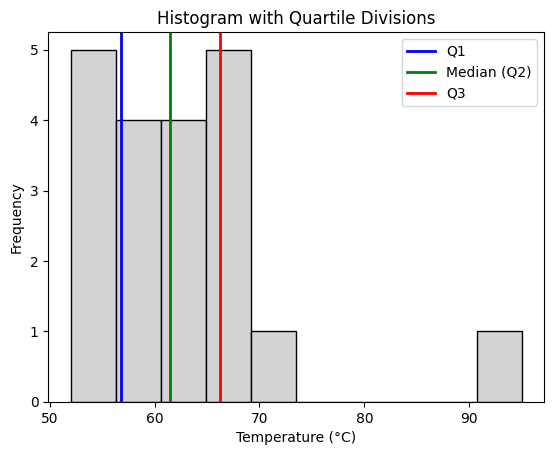

In [8]:
plt.figure()

# Histogram
plt.hist(data, bins=10, color="lightgray", edgecolor="black")

# Quartile lines with different colors
plt.axvline(q1, color="blue", linewidth=2, label="Q1")
plt.axvline(q2, color="green", linewidth=2, label="Median (Q2)")
plt.axvline(q3, color="red", linewidth=2, label="Q3")

plt.title("Histogram with Quartile Divisions")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.legend()  # Show labels
plt.show()

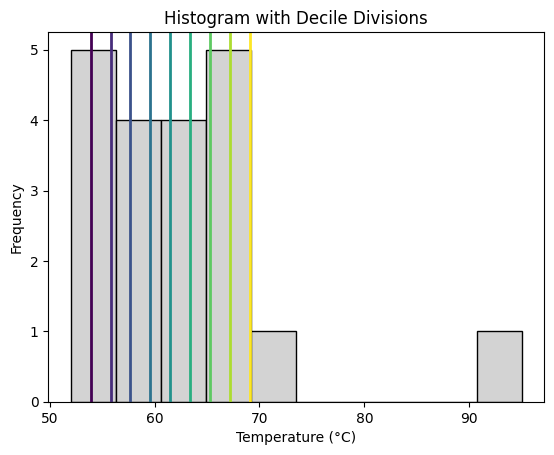

In [9]:
plt.figure()

# Histogram
plt.hist(data, bins=10, color="lightgray", edgecolor="black")

# Generate distinct colors
colors = plt.cm.viridis(np.linspace(0, 1, len(deciles)))

# Plot each decile with different color
for d, c in zip(deciles, colors):
    plt.axvline(d, color=c, linewidth=2)

plt.title("Histogram with Decile Divisions")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

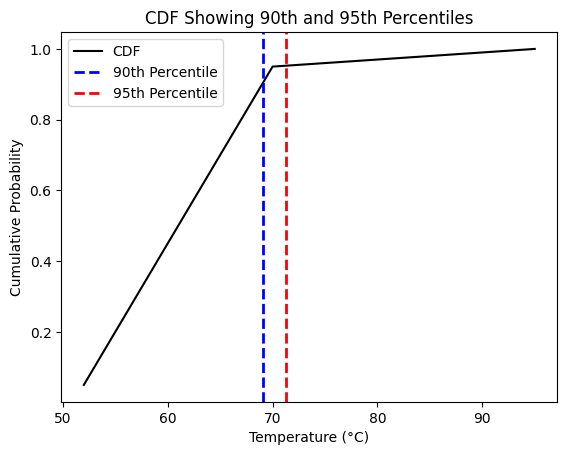

In [10]:
# -----------------------------
# Plot 3: CDF with 90th and 95th Percentiles
# -----------------------------
cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)

plt.figure()

# Plot CDF
plt.plot(sorted_data, cdf, color="black", label="CDF")

# 90th percentile
plt.axvline(p90, color="blue", linewidth=2, linestyle="--", label="90th Percentile")

# 95th percentile
plt.axvline(p95, color="red", linewidth=2, linestyle="--", label="95th Percentile")

plt.title("CDF Showing 90th and 95th Percentiles")
plt.xlabel("Temperature (°C)")
plt.ylabel("Cumulative Probability")

plt.legend()
plt.show()

In [11]:
# ---- IQR Calculation ----
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [12]:
# Detect outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Detected Outliers:", outliers)

Q1: 56.75
Q3: 66.25
IQR: 9.5
Lower Bound: 42.5
Upper Bound: 80.5
Detected Outliers: [95]


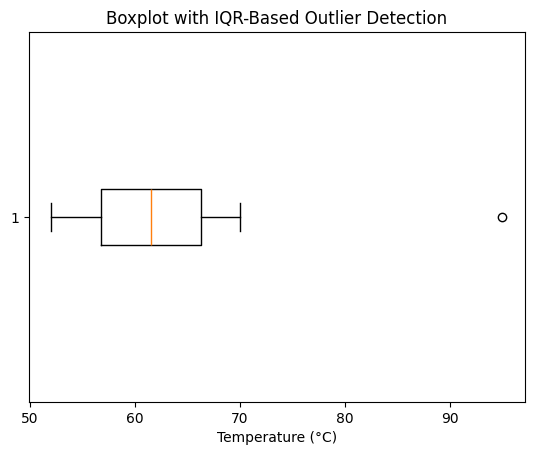

In [13]:
# -----------------------------
# Plot 4: Boxplot (Shows Outlier Automatically)
# -----------------------------
plt.figure()
plt.boxplot(data, vert=False)
plt.title("Boxplot with IQR-Based Outlier Detection")
plt.xlabel("Temperature (°C)")
plt.show()

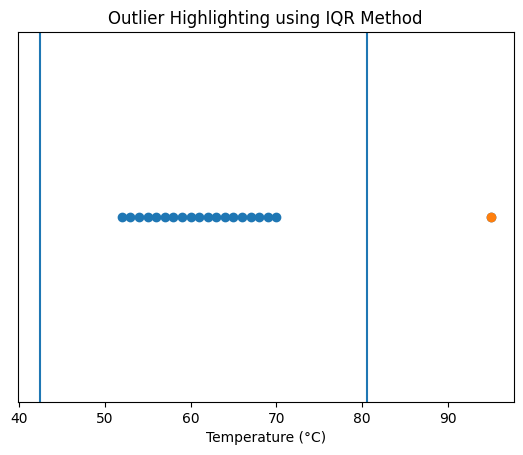

In [14]:
# -----------------------------
# Plot 5: Data Points with Outliers Highlighted
# -----------------------------
plt.figure()

# Plot all data points
plt.scatter(data, np.zeros_like(data))

# Highlight outliers
if len(outliers) > 0:
    plt.scatter(outliers, np.zeros_like(outliers))

plt.axvline(lower_bound)
plt.axvline(upper_bound)

plt.title("Outlier Highlighting using IQR Method")
plt.xlabel("Temperature (°C)")
plt.yticks([])
plt.show()
